Matrix sizes: [3, 6, 12, 24, 48, 96, 192, 384]
Size 3x3:  Naive: 0.000076s  NumPy: 0.000106s
Size 6x6:  Naive: 0.000058s  NumPy: 0.000017s
Size 12x12:  Naive: 0.000375s  NumPy: 0.000024s
Size 24x24:  Naive: 0.002587s  NumPy: 0.000039s
Size 48x48:  Naive: 0.020288s  NumPy: 0.000060s
Size 96x96:  Naive: 0.160410s  NumPy: 0.000240s
Size 192x192:  Naive: 1.237582s  NumPy: 0.000852s
Size 384x384:  Naive: 11.312838s  NumPy: 0.004626s


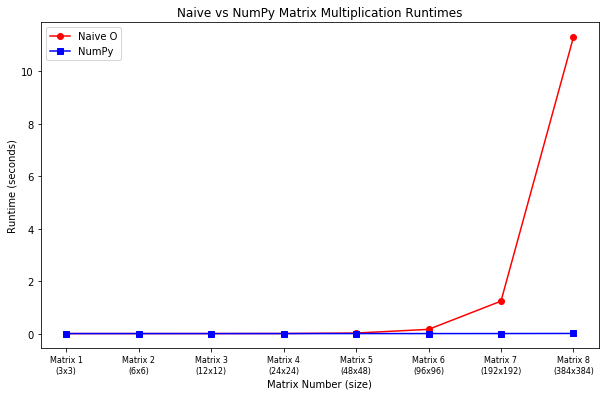

In [6]:
import numpy as np
import time
import matplotlib.pyplot as plt

# naive matrix multiplier
def naive_matrix_multiplication(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]
    
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    
    return C

# build 8 pairs of matrices sizes: 3, 6, 12, 24, 48, 96, 192, 384
sizes = []
size = 3
for i in range(8):
    sizes.append(size)
    size = size * 2

print("Matrix sizes:", sizes)

# lists to store runtimes
naive_times = []
numpy_times = []

for n in sizes:
    # generate random matrices
    A = np.random.rand(n, n)
    B = np.random.rand(n, n)

    # convert to lists for naive
    A_list = A.tolist()
    B_list = B.tolist()

    # time naive 
    start = time.time()
    naive_matrix_multiplication(A_list, B_list)
    end = time.time()
    naive_times.append(end - start)

    # time numpy 
    start = time.time()
    np.dot(A, B)
    end = time.time()
    numpy_times.append(end - start)

    print(f"Size {n}x{n}:  Naive: {naive_times[-1]:.6f}s  NumPy: {numpy_times[-1]:.6f}s")

# plotting
matrix_numbers = list(range(1, 9))

plt.figure(figsize=(10, 6))
plt.plot(matrix_numbers, naive_times, marker='o', label='Naive O', color='red')
plt.plot(matrix_numbers, numpy_times, marker='s', label='NumPy', color='blue')

plt.xticks(matrix_numbers, [f"Matrix {i}\n({sizes[i-1]}x{sizes[i-1]})" for i in matrix_numbers], fontsize=8)
plt.xlabel("Matrix Number (size)")
plt.ylabel("Runtime (seconds)")
plt.title("Naive vs NumPy Matrix Multiplication Runtimes")
plt.legend()
plt.show()